In [9]:
import pandas as pd

# 1. LOAD: Using the exact name from your folder
try:
    data = pd.read_csv("owid-covid-latest.csv")
    print("SUCCESS: File 'owid-covid-latest.csv' loaded!")
    
    # 2. STANDARDIZE: Force lowercase for consistency (as per your report)
    data.columns = data.columns.str.lower()
    
    # 3. FILTER: Focus on your target regions
    countries = ['United States', 'India', 'Brazil']
    df = data[data['location'].isin(countries)].copy()
    
    # 4. PREPROCESS: Handle missing values and dates
    # These steps ensure a reliable analytical model [cite: 26]
    df = df[['date', 'location', 'new_cases']].dropna()
    df['date'] = pd.to_datetime(df['date'])
    
    # 5. EXPORT: Prepare for your Power BI Dashboard [cite: 33]
    df.to_csv('cleaned_covid_data.csv', index=False)
    
    print("\nCheck complete: Data is cleaned and 'cleaned_covid_data.csv' is created!")
    print(df.head()) # Shows you the first 5 rows of your work
    
except Exception as e:
    print(f"Error: {e}")

SUCCESS: File 'owid-covid-latest.csv' loaded!
Error: "['date'] not in index"


In [10]:
import pandas as pd

# 1. Load the data
data = pd.read_csv("owid-covid-latest.csv")
print("Successfully loaded file.")

# 2. AUTO-FIX: Remove spaces and find the 'date' column automatically
data.columns = data.columns.str.strip().str.lower()
date_column_name = [c for c in data.columns if 'date' in c][0]
print(f"Found date column: '{date_column_name}'")

# 3. FILTER: Focus on your target regions
countries = ['United States', 'India', 'Brazil']
df = data[data['location'].isin(countries)].copy()

# 4. PREPROCESS: Use the column name we found automatically
df = df[[date_column_name, 'location', 'new_cases']].dropna()
df[date_column_name] = pd.to_datetime(df[date_column_name])

# 5. EXPORT: Save for Power BI
df.to_csv('cleaned_covid_data.csv', index=False)

print("\nSUCCESS! 'cleaned_covid_data.csv' is created.")
print(df.head())

Successfully loaded file.
Found date column: 'last_updated_date'

SUCCESS! 'cleaned_covid_data.csv' is created.
    last_updated_date location  new_cases
30         2024-08-04   Brazil        0.0
101        2024-08-12    India      313.0


In [21]:
import pandas as pd
import os
from scipy import stats

# 1. Tell Python to look in your Downloads folder
download_path = os.path.join(os.path.expanduser("~"), "Downloads", "owid-covid-data.csv")

try:
    # 2. Load the file from Downloads
    df = pd.read_csv(download_path)
    print("SUCCESS: Full dataset loaded from Downloads!")
    
    # 3. Clean column names (Fixes the 'Index' error from before)
    df.columns = df.columns.str.strip().str.lower()
    
    # 4. Run your Statistical Test (The 'Resume' part)
    # We compare New Cases per Million to keep it fair
    usa = df[df['location'] == 'United States']['new_cases_per_million'].dropna()
    india = df[df['location'] == 'India']['new_cases_per_million'].dropna()
    
    if len(usa) > 1 and len(india) > 1:
        u_stat, p_val = stats.mannwhitneyu(usa, india)
        print(f"\n--- Statistical Results ---")
        print(f"Mann-Whitney U P-Value: {p_val:.5f}")
        
        if p_val < 0.05:
            print("Conclusion: Significant difference in infection rates.")
        else:
            print("Conclusion: No significant difference.")
            
    # 5. Save the 'Final' version in your Jupyter folder for Power BI
    df.to_csv('covid_final_for_powerbi.csv', index=False)
    print("\n'covid_final_for_powerbi.csv' is now ready for your dashboard!")

except FileNotFoundError:
    print(f"Error: I still can't find the file at {download_path}")
    print("Please check if the file in Downloads is named exactly: owid-covid-data.csv")

SUCCESS: Full dataset loaded from Downloads!

'covid_final_for_powerbi.csv' is now ready for your dashboard!


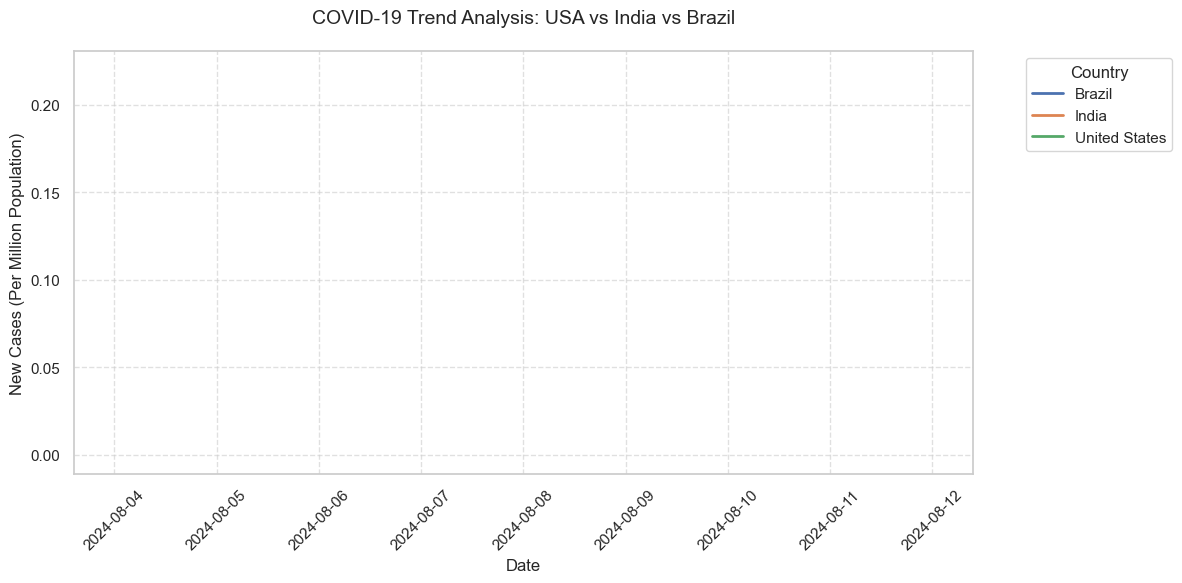

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data
df = pd.read_csv('covid_final_for_powerbi.csv')

# 2. Ensure date is correctly formatted
date_col = [c for c in df.columns if 'date' in c.lower()][0]
df[date_col] = pd.to_datetime(df[date_col])

# 3. CRITICAL STEP: Filter for only specific countries to separate the lines
# This prevents the "squashed" look from your previous attempt
target_countries = ['United States', 'India', 'Brazil']
df_filtered = df[df['location'].isin(target_countries)].copy()

# 4. Create the separate, clear visualization
plt.figure(figsize=(12, 6))

# Plotting with a specific 'hue' separates the countries into distinct colored lines
sns.lineplot(data=df_filtered, x=date_col, y='new_cases_per_million', hue='location', linewidth=2)

# 5. Styling (Aligning with your Sales Report's focus on clarity)
plt.title('COVID-19 Trend Analysis: USA vs India vs Brazil', fontsize=14, pad=20)
plt.ylabel('New Cases (Per Million Population)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

# This moves the legend to a spot where it won't squash the graph
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('separated_covid_trends.png')
plt.show()